# Heart Disease Prediction using Machine Learning

This notebook demonstrates a complete, minimal, and clean end-to-end Machine Learning pipeline to predict heart disease using the UCI Heart Disease dataset.

### Project Workflow:
1. **Data Loading**: Retrieve the dataset from the public UCI repository.
2. **Data Cleaning**: Handle missing values and duplicate rows.
3. **Data Wrangling**: Feature-target separation, train-test splitting, and feature scaling.
4. **Model Training**: Train Logistic Regression and Decision Tree Classifiers.
5. **Evaluation & Visualization**: Evaluate models using accuracy, classification reports, confusion matrices, and visualize the Decision Tree structure.

## 1. Import Libraries and Load Data

We start by importing the necessary libraries (`pandas`, `numpy`, `scikit-learn`, `matplotlib`) and loading the Cleveland Heart Disease dataset from the UCI Machine Learning Repository.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the public URL for the UCI Heart Disease dataset (Cleveland database)
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Define the standard column names
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

# Load the dataset. The dataset represents missing values with '?'
df = pd.read_csv(data_url, names=column_names, na_values="?")

# Preview the first few rows of the data
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 2. Data Cleaning

We inspect the dataset for missing values and duplicate rows, and then remove them to ensure high-quality training data.

In [2]:
print("Initial dataset shape:", df.shape)
print("Missing values per column:\n", df.isnull().sum())

# Drop missing values
df = df.dropna()

# Drop duplicate records, if any
df = df.drop_duplicates()

print("\nCleaned dataset shape:", df.shape)

Initial dataset shape: (303, 14)
Missing values per column:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Cleaned dataset shape: (297, 14)


## 3. Data Wrangling

We perform the following tasks:
1. **Binarize the Target**: The raw target values range from 0 (healthy) to 1-4 (different stages of heart disease). We map these to 0 (no heart disease) and 1 (heart disease present).
2. **Split Features and Target**: Separate features ($X$) from the label ($y$).
3. **Train-Test Split**: Partition the data into an 80% training set and a 20% test set.
4. **Feature Scaling**: Standardize the features so that they have a mean of 0 and variance of 1.

In [3]:
# Convert target to binary class: 0 for normal, 1 for heart disease
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply basic feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set features shape:", X_train_scaled.shape)
print("Test set features shape:", X_test_scaled.shape)

Training set features shape: (237, 13)
Test set features shape: (60, 13)


## 4. Model Training

We initialize and train two classifiers: Logistic Regression and a Decision Tree Classifier (capped at a max depth of 3 for visualization clarity).

In [4]:
# Initialize classifiers
lr_model = LogisticRegression(random_state=42)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# Train Logistic Regression
lr_model.fit(X_train_scaled, y_train)

# Train Decision Tree
dt_model.fit(X_train_scaled, y_train)

print("Models successfully trained.")

Models successfully trained.


## 5. Model Evaluation & Decision Tree Visualization

We make predictions on the test set and evaluate both models. Additionally, we visualize the trained Decision Tree structure.

=== Logistic Regression Evaluation ===
Accuracy Score: 0.8333

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Confusion Matrix:
[[28  4]
 [ 6 22]]


=== Decision Tree Evaluation ===
Accuracy Score: 0.8000

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        32
           1       0.79      0.79      0.79        28

    accuracy                           0.80        60
   macro avg       0.80      0.80      0.80        60
weighted avg       0.80      0.80      0.80        60

Confusion Matrix:
[[26  6]
 [ 6 22]]


=== Decision Tree Structure (Text Rules) ===
|--- thal <= -0.16
|   |--- ca <= -0.20
|   |   |--- oldp

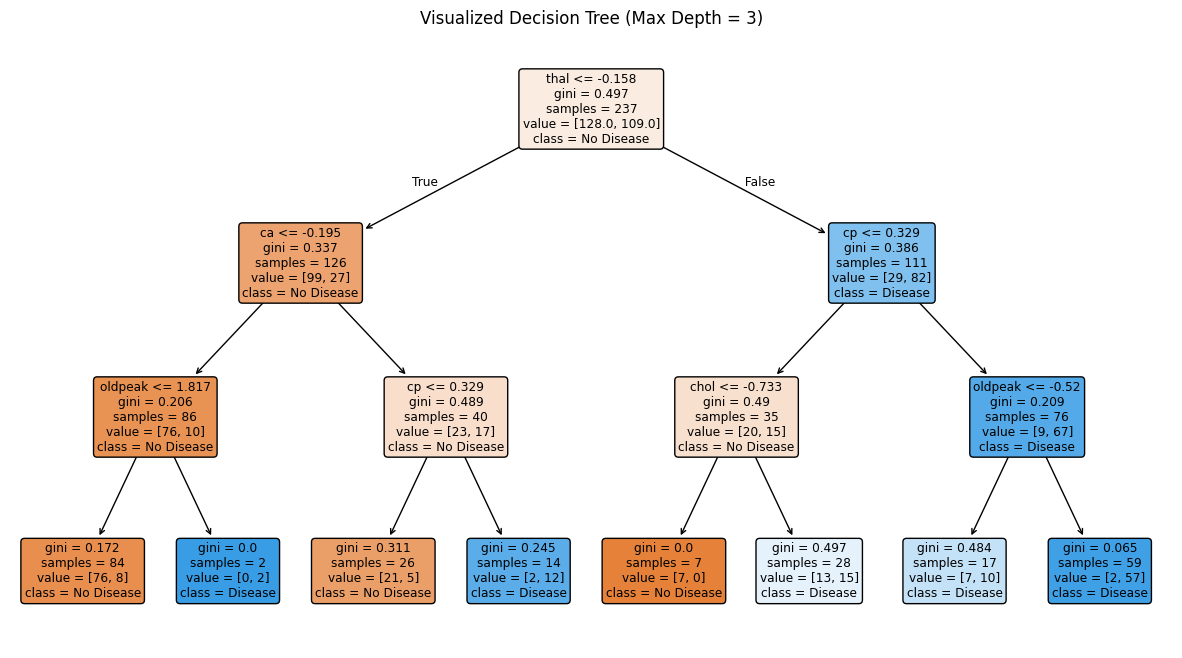

In [5]:
# --- 5.1 Logistic Regression Evaluation ---
y_pred_lr = lr_model.predict(X_test_scaled)
print("=== Logistic Regression Evaluation ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\n" + "="*40 + "\n")

# --- 5.2 Decision Tree Evaluation ---
y_pred_dt = dt_model.predict(X_test_scaled)
print("=== Decision Tree Evaluation ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\n" + "="*40 + "\n")

# --- 5.3 Decision Tree Visualizations ---
print("=== Decision Tree Structure (Text Rules) ===")
tree_rules = export_text(dt_model, feature_names=list(X.columns))
print(tree_rules)

# Graphical Plot of the Decision Tree
plt.figure(figsize=(15, 8))
plot_tree(
    dt_model,
    feature_names=list(X.columns),
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True
)
plt.title("Visualized Decision Tree (Max Depth = 3)")
plt.show()